In [1]:
import sys
from scipy.stats import sem
sys.path.append('/Users/michaelfinch/CA1-interneuron-GLM')

from utils_TCA_clustering_scratchpad import *
from GLM_regression_plotting import *


from modelling_to_date_utils import *

import os, time, sys, platform

/Users/michaelfinch/CA1-interneuron-GLM/utils.py:7: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


In [2]:
# activity_dict, double_predicted_activity_dict_NDNF_new, filtered_factors_dict, double_new_NDNF_activity_dict, double_new_NDNF_velocity_dict, double_residual_activity_dict_NDNF_new = load_data_double(name="NDNFanalC", double_track=False)
# activity_dict, filtered_factors_dict, double_new_NDNF_activity_dict_100, double_new_NDNF_velocity_dict_100, double_residual_activity_dict_NDNF_new_100 = load_data_double(name="NDNFanalC", double_track=True)

# GLM_params, activity_dict, double_predicted_activity_dict_NDNF_new, factors_dict, filtered_factors_dict, residual_activity_dict_NDNF_new = load_data_regular(name="NDNFanalC", new_NDNF=True)
# GLM_params_old_NDNF, activity_dict_old_NDNF, double_predicted_activity_dict_NDNF_old, factors_dict_old_NDNF, filtered_factors_dict_old_NDNF, residual_activity_dict_NDNF_old = load_data_regular(name="NDNFindivsomata_GLM", new_NDNF=False)
GLM_params_SST, activity_dict_SST, double_predicted_activity_dict_SST, factors_dict_SST, filtered_factors_dict_SST, residual_activity_dict_SST = load_data_regular(file_path='/Users/michaelfinch/CA1-interneuron-GLM', name="SSTindivsomata_GLM", new_NDNF=False)
GLM_params_EC, activity_dict_EC, double_predicted_activity_dict_EC, factors_dict_EC, filtered_factors_dict_EC, residual_activity_dict_EC = load_data_regular(file_path='/Users/michaelfinch/CA1-interneuron-GLM', name="EC_GLM", new_NDNF=False)


GLM_params_NDNF_newest, activity_dict_NDNF_newest, double_predicted_activity_dict_NDNF_newest, factors_dict_NDNF_newest, filtered_factors_dict_NDNF_newest, residual_activity_dict_NDNF_newest = load_data_regular(file_path='/Users/michaelfinch/CA1-interneuron-GLM', name="NDNF_E1A1B", new_NDNF=True)

fixed_residual_activity_dict_NDNF_newest = {}
for idx, animal in enumerate(residual_activity_dict_NDNF_newest):
    if 17 < idx < 31:
        fixed_residual_activity_dict_NDNF_newest[f"animal_{idx+1}"] = residual_activity_dict_NDNF_newest[animal]

fixed_activity_dict_NDNF_newest = {}
for idx, animal in enumerate(activity_dict_NDNF_newest):
    if 17 < idx < 31:
        fixed_activity_dict_NDNF_newest[f"animal_{idx+1}"] = activity_dict_NDNF_newest[animal]

fixed_filtered_factors_dict_NDNF_newest = {}
for idx, animal in enumerate(filtered_factors_dict_NDNF_newest):
    if 17 < idx < 31:
        fixed_filtered_factors_dict_NDNF_newest[f"animal_{idx+1}"] = filtered_factors_dict_NDNF_newest[animal]



In [3]:
from Fixing_dend_models_presentation import * #(_sanitize_velocity_cm_s, _get_peak_rss_bytes, _get_current_rss_bytes, get_dend_VM_cell_type, exp_kernel)
import random

mean_new_average_vel_array = get_real_velocity_array(filtered_factors_dict_EC, filtered_factors_dict_SST, fixed_filtered_factors_dict_NDNF_newest)

In [4]:
############## find sigma and mu 

In [5]:
velocity_list = get_vel_formatted(activity_dict_EC, factors_dict_EC)
velocity_list[0].shape

NameError: name 'get_vel_formatted' is not defined

In [11]:
def get_dend_contribution(residual_activity_dict_EC, fixed_residual_activity_dict_NDNF_newest, residual_activity_dict_SST, factors_dict_EC, factors_dict_SST, factors_dict_NDNF_newest, GLM_params_EC, GLM_params_NDNF_newest, GLM_params_SST, mean_new_average_vel_array, real_vel=None, constant_vel=None, use_residuals=True, use_model_EC=False, multiple_dendrites=False, add_inh=None, seed=0, SST_bias_factor=None, dist=None, use_averaged_velocity=None, make_it_spike=False, store_intermediates=False):
    
    SEED = seed
    np.random.seed(SEED)
    random.seed(SEED)
    rng = np.random.default_rng(SEED)

    n_EC = 792
    n_SST = 75
    n_NDNF = 115
    n_dendrites=100


    dt_constant=0.001

    tau_ms  = 5.0
    dt_ms   = dt_constant * 1000.0      # 1 ms
    AMP     = 1.0                      # mV
    MODE    = "peak"                    # "area" or "peak"
    kernel  = exp_kernel(tau_ms, dt_ms, n_taus=5, norm=MODE, target=AMP)


    if use_model_EC:

        if make_it_spike:
            
            n_EC = 792
            pos_bins = 50
            n_trials = 58

            animal_velocity_list_cm_sec = get_vel_formatted(activity_dict_EC, factors_dict_EC)
            data_normalized_list, r2_list = get_correlation(activity_dict_EC, factors_dict_EC)
            overall_mean = np.mean(data_normalized_list)
            synthetic_data_plus_vel_list, synthetic_activity = get_synthetic_data(n_EC, pos_bins, n_trials, overall_mean, animal_velocity_list_cm_sec, r2_list)

            animal_velocity_array = np.array(animal_velocity_list_cm_sec)
            an_velocity = np.mean(animal_velocity_array, axis=0) / 100


            print(f"len(synthetic_data_plus_vel_list) {len(synthetic_data_plus_vel_list)}")
            print(f"synthetic_data_plus_vel_list[0].shape {synthetic_data_plus_vel_list[0].shape}")

            dend_vm_list, weights_EC, last_EPSP = turn_rates_into_spikes(synthetic_data_plus_vel_list, an_velocity, dist, kernel, dt_constant=dt_constant, n_dendrites=100, store_intermediates=False, rng=rng)

            num_trials   = len(dend_vm_list)
            n_dendrites_ = dend_vm_list[0].shape[0]   # assume constant across trials


            # dend_vm_list: list of 2D arrays, each (n_dendrites, T_i)

            num_trials = len(dend_vm_list)
            n_dendrites_ = dend_vm_list[0].shape[0]
            max_T = max(arr.shape[1] for arr in dend_vm_list)  # <-- time axis length

            dend_vm_padded = np.full((num_trials, n_dendrites_, max_T), np.nan, dtype=np.float32)

            for i, arr in enumerate(dend_vm_list):
                if arr.shape[0] != n_dendrites_:
                    raise ValueError(f"Trial {i}: n_dendrites mismatch: {arr.shape[0]} != {n_dendrites_}")
                Ti = arr.shape[1]               # current trial's time length
                dend_vm_padded[i, :, :Ti] = arr # pad along time axis


            print(f"dend_vm_padded.shape {dend_vm_padded.shape}")

            Vm_list = []
            for dend in range(dend_vm_padded.shape[1]):
                trials_by_time = dend_vm_padded[:,dend,:]
                Vm, _, _ = activity_to_dend_vm_2d(
                trials_by_time,
                Vrest=-70.0,
                vm_scale=0.1,
                center_across="time")
                Vm_list.append(Vm)

            activity_EC = np.array(Vm_list)

            activity_NDNF=0
            activity_SST=0 
            NDNF_sf_opt=0 
            SST_sf_opt=0 
            NDNF_contribution_sum=0
            SST_contribution_sum=0
            weights_SST=0
            weights_NDNF=0

            return an_velocity, activity_EC, activity_NDNF, activity_SST, NDNF_sf_opt, SST_sf_opt, NDNF_contribution_sum, SST_contribution_sum, weights_EC, weights_SST, weights_NDNF, last_EPSP

        
        else:
            random.seed(seed)
            ts_list = []
            for i in range(58):
                ts = random_timeseries(1.0, 1., 49)
                ts_list.append(ts)

            dend_contribution_EC = np.array(ts_list).T
            print(dend_contribution_EC.shape)

            if constant_vel:
                an_velocity = np.full(dend_contribution_EC.shape, 0.43)
            else:
                an_velocity = np.tile(mean_new_average_vel_array[:,None], (1,58))


            # dend_contribution_EC /= dend_contribution_EC

            return dend_contribution_EC, an_velocity 
            

        # rng = np.random.default_rng(seed=40)

        # pos_bins = 150
        # real_pos=50
        # trials = 58
        # dend_contribution_EC = np.zeros((pos_bins, trials))

        # # Fixed Gaussian centers
        # base_centers = np.arange(0, pos_bins+1, 5)  # bin 2, 7, 12, ..., 47
        # width = 2.5
        # for i in range(trials):
        #     for center in base_centers:
        #         # Add jitter to the center (±1 bin)
        #         jittered_center = center + rng.choice([-1, 0, 1])

        #         # Make sure jittered center stays within bounds
        #         jittered_center = np.clip(jittered_center, 0, pos_bins - 1)

        #         amplitude = rng.uniform(0.01, 0.02)  # still jitter amplitude too
        #         gaussian = norm.pdf(np.arange(pos_bins), loc=jittered_center, scale=width)
        #         gaussian /= np.max(gaussian)
        #         dend_contribution_EC[:, i] += amplitude * gaussian

        # final_dend = dend_contribution_EC[real_pos:real_pos*2, :]
        # # Normalize globally if needed
        # final_dend /= np.max(final_dend)
        # if constant_vel:
        #     an_velocity = np.full(final_dend.shape, 0.43)
        # else:
        #     an_velocity = np.tile(mean_new_average_vel_array[:,None], (1,58))
            
        # return final_dend, an_velocity 
    
    else:
        if use_residuals:
            dend_contribution_EC, an_velocity_EC, dend_list_EC = get_dend_VM_cell_type(residual_activity_dict_EC, factors_dict_EC, mean_new_average_vel_array, GLM_params_EC, 1.0, amplitude=-0.5, vel=0.43, norm="min_max", add_vel_contribution=real_vel, const_vel=constant_vel, use_averaged_velocity=use_averaged_velocity, add_inh=add_inh, make_it_spike=make_it_spike)
            dend_contribution_NDNF, an_velocity_NDNF, dend_list_NDNF = get_dend_VM_cell_type(fixed_residual_activity_dict_NDNF_newest, factors_dict_NDNF_newest, mean_new_average_vel_array, GLM_params_NDNF_newest, 1.0, amplitude=-0.5, vel=0.43, norm="min_max", add_vel_contribution=real_vel, const_vel=constant_vel, use_averaged_velocity=use_averaged_velocity, add_inh=add_inh, make_it_spike=make_it_spike)
            dend_contribution_SST, an_velocity_SST, dend_list_SST = get_dend_VM_cell_type(residual_activity_dict_SST, factors_dict_SST, mean_new_average_vel_array, GLM_params_SST, 1.0, amplitude=-0.5, vel=0.43, norm="min_max", add_vel_contribution=real_vel, const_vel=constant_vel, use_averaged_velocity=use_averaged_velocity, add_inh=add_inh, make_it_spike=make_it_spike)
            
            EC = dend_contribution_EC.copy()
            NDNF = dend_contribution_NDNF.copy()
            SST = dend_contribution_SST.copy()
            
            if add_inh=='neither':
                an_velocity = an_velocity_EC 
                SST_sf_opt = 0
                NDNF_sf_opt = 0
                NDNF_contribution_sum = 0
                SST_contribution_sum = 0

            elif add_inh=='sst':
                SST_sf_opt, info = fit_sst_scale_to_cancel_ec(dend_contribution_EC, dend_contribution_SST)
                NDNF_sf_opt=0
                NDNF_contribution_sum = 0
                SST_contribution_sum = 0

                an_velocity = np.nanmean(np.stack([an_velocity_EC, an_velocity_SST], axis=0), axis=0)

            else:
                # result = minimize(loss_fn, x0=[1.0, 1.0], bounds=[(0, 5), (0, 5)], args=(EC, NDNF, SST))
                # NDNF_sf_opt, SST_sf_opt = result.x

                res = fit_equal_contrib_L2(EC, NDNF, SST, SST_bias_factor=SST_bias_factor)
                NDNF_sf_opt = res["ndnf_sf"]
                SST_sf_opt  = res["sst_sf"]
                NDNF_contribution_sum = res["contrib_L2_ndnf"]
                SST_contribution_sum = res["contrib_L2_sst"]

                an_velocity = np.nanmean(np.stack([an_velocity_EC, an_velocity_SST, an_velocity_NDNF], axis=0), axis=0)


        else:
            dend_contribution_EC, an_velocity_EC, dend_list_EC = get_dend_VM_cell_type(residual_activity_dict_EC, factors_dict_EC, mean_new_average_vel_array, GLM_params_EC, 1.0, amplitude=-0.5, vel=0.43, norm="min_max", add_vel_contribution=real_vel, const_vel=constant_vel, use_averaged_velocity=use_averaged_velocity, add_inh=add_inh, make_it_spike=make_it_spike)
            dend_contribution_NDNF, an_velocity_SST, dend_list_NDNF = get_dend_VM_cell_type(fixed_residual_activity_dict_NDNF_newest, factors_dict_NDNF_newest, mean_new_average_vel_array, GLM_params_NDNF_newest, 1.0, amplitude=-0.5, vel=0.43, norm="min_max", add_vel_contribution=real_vel, const_vel=constant_vel, use_averaged_velocity=use_averaged_velocity, add_inh=add_inh, make_it_spike=make_it_spike)
            dend_contribution_SST, an_velocity_NDNF, dend_list_SST = get_dend_VM_cell_type(residual_activity_dict_SST, factors_dict_SST, mean_new_average_vel_array, GLM_params_SST, 1.0, amplitude=-0.5, vel=0.43, norm="min_max", add_vel_contribution=real_vel, const_vel=constant_vel, use_averaged_velocity=use_averaged_velocity, add_inh=add_inh, make_it_spike=make_it_spike)
            
            EC = dend_contribution_EC.copy()
            NDNF = dend_contribution_NDNF.copy()
            SST = dend_contribution_SST.copy()

            if add_inh=='neither':
                an_velocity = an_velocity_EC 
                SST_sf_opt = 0
                NDNF_sf_opt = 0
                NDNF_contribution_sum = 0
                SST_contribution_sum = 0

            elif add_inh=='sst':
                SST_sf_opt, info = fit_sst_scale_to_cancel_ec(dend_contribution_EC, dend_contribution_SST)
                NDNF_sf_opt=0
                NDNF_contribution_sum = 0
                SST_contribution_sum = 0
                an_velocity = np.nanmean(np.stack([an_velocity_EC, an_velocity_SST], axis=0), axis=0)

            else:
                # result = minimize(loss_fn, x0=[1.0, 1.0], bounds=[(0, 5), (0, 5)], args=(EC, NDNF, SST))
                # NDNF_sf_opt, SST_sf_opt = result.x
                res = fit_equal_contrib_L2(EC, NDNF, SST, SST_bias_factor=SST_bias_factor)
                NDNF_sf_opt = res["ndnf_sf"]
                SST_sf_opt  = res["sst_sf"]
                NDNF_contribution_sum = res["contrib_L2_ndnf"]
                SST_contribution_sum = res["contrib_L2_sst"]

                an_velocity = np.nanmean(np.stack([an_velocity_EC, an_velocity_SST, an_velocity_NDNF], axis=0), axis=0)


        if multiple_dendrites:

            dend_contribution_EC, an_velocity, dend_list_EC = get_dend_VM_cell_type(residual_activity_dict_EC, factors_dict_EC, mean_new_average_vel_array, GLM_params_EC, 1.0, amplitude=-0.5, vel=0.43, norm="min_max", add_vel_contribution=real_vel, const_vel=constant_vel, use_averaged_velocity=use_averaged_velocity, add_inh=add_inh, make_it_spike=make_it_spike)
            dend_contribution_NDNF, an_velocity, dend_list_NDNF = get_dend_VM_cell_type(fixed_residual_activity_dict_NDNF_newest, factors_dict_NDNF_newest, mean_new_average_vel_array, GLM_params_NDNF_newest, 1.0, amplitude=-0.5, vel=0.43, norm="min_max", add_vel_contribution=real_vel, const_vel=constant_vel, use_averaged_velocity=use_averaged_velocity, add_inh=add_inh, make_it_spike=make_it_spike)
            dend_contribution_SST, an_velocity, dend_list_SST = get_dend_VM_cell_type(residual_activity_dict_SST, factors_dict_SST, mean_new_average_vel_array, GLM_params_SST, 1.0, amplitude=-0.5, vel=0.43, norm="min_max", add_vel_contribution=real_vel, const_vel=constant_vel, use_averaged_velocity=use_averaged_velocity, add_inh=add_inh, make_it_spike=make_it_spike)
            


            if make_it_spike:

                try:
                    import psutil
                    _PROC = psutil.Process(os.getpid())
                except Exception:
                    psutil = None
                    _PROC = None


                # def turn_rates_into_spikes(dend_list_EC):


                #     EC_input_matrix = np.stack(dend_list_EC[:n_EC], axis=0)
                #     SST_input_matrix = np.stack(dend_list_SST[:n_SST], axis=0)
                #     NDNF_input_matrix = np.stack(dend_list_NDNF[:n_NDNF], axis=0)

                    

                #     n_pos = EC_input_matrix.shape[1]
                #     n_trials = EC_input_matrix.shape[2]
                #     dx = 180.0 / n_pos  

                #     vel = an_velocity
                #     if vel.shape != (n_pos, n_trials):
                #         raise ValueError(f"velocity shape {vel.shape} != {(n_pos, n_trials)}")

                #     L_prev = 500
    
                #     # precomputed_prepend = np.zeros(L_prev)
                #     weights_EC = sample_weights(dist, n_EC, n_dendrites, rng=rng)
                #     max_length = 0
                #     dend_vm_list = []  

                #     proc_peak_start = _get_peak_rss_bytes()   # peak at loop start

                #     warped_list = []

                #     last_EPSP = None

                #     for t in range(EC_input_matrix.shape[2]):

                #         trial_wall_start = time.perf_counter()
                #         trial_peak_before = _get_peak_rss_bytes()
                #         trial_curr_before = _get_current_rss_bytes()

                #         start_time = time.time()
                #         v_cm_s = _sanitize_velocity_cm_s(an_velocity[:, t]) 
                #         dt_s   = dx / v_cm_s                             
                #         edges_s = np.concatenate(([0.0], np.cumsum(dt_s)))
                #         total_time = float(edges_s[-1])





                #         # constant-time axis in seconds
                #         t_axis = np.arange(0.0, total_time, dt_constant, dtype=np.float64)
                #         print(f"len(t_axis) {len(t_axis)}")
                #         max_time_over_cells = 0
                #         T = t_axis.size

                #         firing_example = EC_input_matrix[0, :, t].astype(np.float64, copy=False)
                #         valid = np.isfinite(firing_example)
                #         time_points = np.cumsum(dt_s)
                        
                #         firing_zero = EC_input_matrix[0, :, t].astype(np.float64, copy=False)
                #         warped_zero = np.interp(t_axis, time_points[valid], firing_zero[valid]).astype(np.float32, copy=False)
                #         holder = warped_zero[:L_prev]

                #         warped_rows = [] if store_intermediates else None

                #         rows = np.empty((n_EC, T), dtype=np.float32)   

                #         two_track_length = np.empty(len(holder) + len(warped_zero))

                #         t_ms = np.arange(two_track_length.size, dtype=int) * dt_ms


                #         for cell in range(n_EC):
                #             firing = EC_input_matrix[cell, :, t].astype(np.float64, copy=False)
                #             valid = np.isfinite(firing)
                #             if valid.sum() >= 2:
                #                 time_points = np.cumsum(dt_s)  # length n_pos

                #                 warped = np.interp(t_axis, time_points[valid], firing[valid]).astype(np.float32, copy=False)
                #                 holder = warped[:L_prev]

                #             else:
                #                 warped = np.full(1, np.nan, dtype=np.float32)
                            
                #             if store_intermediates:
                #                 warped_rows.append(warped)

                #             two_track_length[:len(holder)] = holder
                #             two_track_length[-len(warped):] = warped

                #             spike_times = get_inhom_poisson_spike_times_by_thinning_real(two_track_length, t_ms, dt=dt_ms, refractory=3., generator=None, rng=rng).astype(int) 
                            
                #             epsps = epsps_event_add(spike_times, two_track_length.shape[0], kernel).astype(np.float16, copy=False)
                #             epsps = epsps[L_prev:]

                #             last_EPSP = epsps

                            
                #             if len(epsps) > max_time_over_cells:
                #                 max_time_over_cells = len(epsps)
                #                 print(f"trial {t} len(epsps) {len(epsps)}")
                #             rows[cell,:] = epsps


                #         warped_list.append(warped_rows) if store_intermediates else None
                        
                #         X_trial = np.stack(rows, axis=0).astype(np.float16, copy=False)

                        

                #         dendy_list = []

                #         for dend in range(n_dendrites):
                #             w = weights_EC[:, dend]            # shape (n_EC,)
                #             vm_t = w @ X_trial 
                #             dendy_list.append(vm_t)
                            
                #         dend_vm_over_time = np.array(dendy_list, dtype=np.float16)


                #         # dend_vm_over_time = weights_EC @ X_trial

                #         if len(dend_vm_over_time) > max_length:
                #             max_length = len(dend_vm_over_time)

                #         dend_vm_list.append(dend_vm_over_time)

                        
                #         end_time = time.time()

                #         end_time = time.time()
                #         # --- memory + timing report ---
                #         trial_wall_end = time.time()
                #         trial_peak_after = _get_peak_rss_bytes()
                #         trial_curr_after = _get_current_rss_bytes()

                #         trial_peak_delta = None if (trial_peak_before is None or trial_peak_after is None) \
                #             else (trial_peak_after - trial_peak_before)
                #         proc_peak_total  = trial_peak_after
                #         proc_peak_since_start = None if (proc_peak_start is None or trial_peak_after is None) \
                #             else (trial_peak_after - proc_peak_start)

                #         print(
                #             f"trial {t:02d}:  time={trial_wall_end - trial_wall_start:6.3f}s  "
                #             f"RSS now={_fmt_bytes(trial_curr_after)}  "
                #             f"trial peak Δ={_fmt_bytes(trial_peak_delta)}  "
                #             f"proc peak={_fmt_bytes(proc_peak_total)}  "
                #             f"(+{_fmt_bytes(proc_peak_since_start)} since start)"
                #         )
                #         print(f"total time {end_time-start_time}")

                #         del rows, X_trial, dend_vm_over_time, epsps, 
                
                #     return dend_vm_list

                print(f"len(dend_list_EC) {len(dend_list_EC)}")
                print(f"dend_list_EC[0].shape {dend_list_EC[0].shape}")

                dend_vm_list, weights_EC, last_EPSP = turn_rates_into_spikes(dend_list_EC, an_velocity, dist, kernel, dt_constant=dt_constant, n_dendrites=100, store_intermediates=False, rng=rng)


                num_trials   = len(dend_vm_list)
                n_dendrites_ = dend_vm_list[0].shape[0]   # assume constant across trials


                print(f"num_trials{num_trials} n_dendrites_ {n_dendrites_}")

                # dend_vm_list: list of 2D arrays, each (n_dendrites, T_i)

                num_trials = len(dend_vm_list)
                n_dendrites_ = dend_vm_list[0].shape[0]
                max_T = max(arr.shape[1] for arr in dend_vm_list)  # <-- time axis length

                print(f"num_trials={num_trials}  n_dendrites_={n_dendrites_}  max_T={max_T}")

                # Preallocate (num_trials, n_dendrites, max_T)
                dend_vm_padded = np.full((num_trials, n_dendrites_, max_T), np.nan, dtype=np.float32)

                for i, arr in enumerate(dend_vm_list):
                    if arr.shape[0] != n_dendrites_:
                        raise ValueError(f"Trial {i}: n_dendrites mismatch: {arr.shape[0]} != {n_dendrites_}")
                    Ti = arr.shape[1]               # current trial's time length
                    dend_vm_padded[i, :, :Ti] = arr # pad along time axis


                print(f"dend_vm_padded.shape {dend_vm_padded.shape}")

                Vm_list = []
                for dend in range(dend_vm_padded.shape[1]):
                    trials_by_time = dend_vm_padded[:,dend,:]
                    Vm, _, _ = activity_to_dend_vm_2d(
                    trials_by_time,
                    Vrest=-70.0,
                    vm_scale=0.1,
                    center_across="time")
                    Vm_list.append(Vm)

                activity_EC = np.array(Vm_list)

                activity_NDNF=0
                activity_SST=0 
                NDNF_sf_opt=0 
                SST_sf_opt=0 
                NDNF_contribution_sum=0
                SST_contribution_sum=0
                weights_SST=0
                weights_NDNF=0

            else:
                n_EC = 792
                n_SST = 75
                n_NDNF = 115
                n_dendrites=100


                EC_input_matrix = np.stack(dend_list_EC[:n_EC], axis=0)
                SST_input_matrix = np.stack(dend_list_SST[:n_SST], axis=0)
                NDNF_input_matrix = np.stack(dend_list_NDNF[:n_NDNF], axis=0)

                weights_EC = sample_weights(dist, n_dendrites, n_EC, rng=rng)
                weights_SST = sample_weights('Equal', n_dendrites, n_SST, rng=rng)
                weights_NDNF = sample_weights('Equal', n_dendrites, n_NDNF, rng=rng)

                activity_EC = get_dendrite_activity(weights_EC, EC_input_matrix, n_dendrites, n_EC)
                activity_SST = get_dendrite_activity(weights_SST, SST_input_matrix, n_dendrites, n_SST)
                activity_NDNF = get_dendrite_activity(weights_NDNF, NDNF_input_matrix, n_dendrites, n_NDNF)

                EC = activity_EC.copy()
                NDNF = activity_NDNF.copy()
                SST = activity_SST.copy()

                if add_inh=='sst':
                    SST_sf_opt, info = fit_sst_scale_to_cancel_ec(activity_EC, activity_SST)
                    NDNF_sf_opt=0
                else:
                    # result = minimize(loss_fn, x0=[1.0, 1.0], bounds=[(0, 5), (0, 5)], args=(EC, NDNF, SST))
                    # NDNF_sf_opt, SST_sf_opt = result.x
                    res = fit_equal_contrib_L2(EC, NDNF, SST, SST_bias_factor=SST_bias_factor)
                    NDNF_sf_opt = res["ndnf_sf"]
                    SST_sf_opt  = res["sst_sf"]
                    NDNF_contribution_sum = res["contrib_L2_ndnf"]
                    SST_contribution_sum = res["contrib_L2_sst"]


            return an_velocity, activity_EC, activity_NDNF, activity_SST, NDNF_sf_opt, SST_sf_opt, NDNF_contribution_sum, SST_contribution_sum, weights_EC, weights_SST, weights_NDNF, last_EPSP
        else:
            return dend_contribution_EC, dend_contribution_NDNF, dend_contribution_SST, an_velocity, NDNF_sf_opt, SST_sf_opt, NDNF_contribution_sum, SST_contribution_sum, last_EPSP

In [12]:
def get_real_velocity_array(filtered_factors_dict_EC, filtered_factors_dict_SST, fixed_filtered_factors_dict_NDNF_newest):
    new_average_vel = []

    for animal in filtered_factors_dict_EC:
        for cell in filtered_factors_dict_EC[animal]:
            new_average_vel.append(np.mean(filtered_factors_dict_EC[animal][cell], axis=1))

    for animal in filtered_factors_dict_SST:
        for cell in filtered_factors_dict_SST[animal]:
            new_average_vel.append(np.mean(filtered_factors_dict_SST[animal][cell], axis=1))

    for animal in fixed_filtered_factors_dict_NDNF_newest:
        for cell in fixed_filtered_factors_dict_NDNF_newest[animal]:
            new_average_vel.append(np.mean(fixed_filtered_factors_dict_NDNF_newest[animal][cell], axis=1))


    new_average_vel_array = np.array(new_average_vel)
    mean_new_average_vel_array = np.mean(new_average_vel_array, axis=0)
    
    return mean_new_average_vel_array


In [13]:
from Fixing_dend_models_presentation import (_sanitize_velocity_cm_s, _get_peak_rss_bytes, _get_current_rss_bytes, get_dend_VM_cell_type, exp_kernel, _fmt_bytes)

In [14]:
def turn_rates_into_spikes(dend_list_EC, an_velocity, dist, kernel, dt_constant=None, n_dendrites=100, store_intermediates=False, rng=None):

    print(f"dt_constant {dt_constant}")

    dt_ms = dt_constant*1000.

    EC_input_matrix = np.stack(dend_list_EC, axis=0)

    print(f"an_velocity.shape {an_velocity.shape}")
    # SST_input_matrix = np.stack(dend_list_SST[:n_SST], axis=0)
    # NDNF_input_matrix = np.stack(dend_list_NDNF[:n_NDNF], axis=0)

    n_EC = EC_input_matrix.shape[0]
    n_pos = EC_input_matrix.shape[1]
    n_trials = EC_input_matrix.shape[2]

    dx = 180.0 / n_pos  

    vel = an_velocity
    if vel.shape != (n_pos, n_trials):
        raise ValueError(f"velocity shape {vel.shape} != {(n_pos, n_trials)}")

    L_prev = 500

    # precomputed_prepend = np.zeros(L_prev)
    weights_EC = sample_weights(dist, n_EC, n_dendrites, rng=rng)
    max_length = 0
    dend_vm_list = []  

    proc_peak_start = _get_peak_rss_bytes()   # peak at loop start

    warped_list = []

    last_EPSP = None

    for t in range(EC_input_matrix.shape[2]):

        trial_wall_start = time.perf_counter()
        trial_peak_before = _get_peak_rss_bytes()
        trial_curr_before = _get_current_rss_bytes()

        start_time = time.time()
        v_cm_s = _sanitize_velocity_cm_s(an_velocity[:, t]) 
        dt_s   = dx / v_cm_s                             
        edges_s = np.concatenate(([0.0], np.cumsum(dt_s)))
        total_time = float(edges_s[-1])


        # constant-time axis in seconds
        t_axis = np.arange(0.0, total_time, dt_constant, dtype=np.float64)
        print(f"len(t_axis) {len(t_axis)}")
        max_time_over_cells = 0
        T = t_axis.size

        firing_example = EC_input_matrix[0, :, t].astype(np.float64, copy=False)
        valid = np.isfinite(firing_example)
        time_points = np.cumsum(dt_s)
        
        firing_zero = EC_input_matrix[0, :, t].astype(np.float64, copy=False)
        warped_zero = np.interp(t_axis, time_points[valid], firing_zero[valid]).astype(np.float32, copy=False)
        holder = warped_zero[:L_prev]

        warped_rows = [] if store_intermediates else None

        rows = np.empty((n_EC, T), dtype=np.float32)   

        two_track_length = np.empty(len(holder) + len(warped_zero))

        t_ms = np.arange(two_track_length.size, dtype=int) * dt_ms


        for cell in range(n_EC):
            firing = EC_input_matrix[cell, :, t].astype(np.float64, copy=False)
            valid = np.isfinite(firing)
            if valid.sum() >= 2:
                time_points = np.cumsum(dt_s)  # length n_pos

                warped = np.interp(t_axis, time_points[valid], firing[valid]).astype(np.float32, copy=False)
                holder = warped[:L_prev]
            else:
                warped = np.full(1, np.nan, dtype=np.float32)
            
            if store_intermediates:
                warped_rows.append(warped)

            two_track_length[:len(holder)] = holder
            two_track_length[-len(warped):] = warped

            spike_times = get_inhom_poisson_spike_times_by_thinning_real(two_track_length, t_ms, dt=dt_ms, refractory=3., generator=None, rng=rng).astype(int) 
            
            epsps = epsps_event_add(spike_times, two_track_length.shape[0], kernel).astype(np.float16, copy=False)
            epsps = epsps[L_prev:]

            last_EPSP = epsps

            
            if len(epsps) > max_time_over_cells:
                max_time_over_cells = len(epsps)
                print(f"trial {t} len(epsps) {len(epsps)}")
            rows[cell,:] = epsps


        warped_list.append(warped_rows) if store_intermediates else None
        
        X_trial = np.stack(rows, axis=0).astype(np.float16, copy=False)

        

        dendy_list = []

        for dend in range(n_dendrites):
            w = weights_EC[:, dend]            # shape (n_EC,)
            vm_t = w @ X_trial 
            dendy_list.append(vm_t)
            
        dend_vm_over_time = np.array(dendy_list, dtype=np.float16)


        # dend_vm_over_time = weights_EC @ X_trial

        if len(dend_vm_over_time) > max_length:
            max_length = len(dend_vm_over_time)

        dend_vm_list.append(dend_vm_over_time)

        
        end_time = time.time()

        end_time = time.time()
        # --- memory + timing report ---
        trial_wall_end = time.time()
        trial_peak_after = _get_peak_rss_bytes()
        trial_curr_after = _get_current_rss_bytes()

        trial_peak_delta = None if (trial_peak_before is None or trial_peak_after is None) \
            else (trial_peak_after - trial_peak_before)
        proc_peak_total  = trial_peak_after
        proc_peak_since_start = None if (proc_peak_start is None or trial_peak_after is None) \
            else (trial_peak_after - proc_peak_start)

        print(
            f"trial {t:02d}:  time={trial_wall_end - trial_wall_start:6.3f}s  "
            f"RSS now={_fmt_bytes(trial_curr_after)}  "
            f"trial peak Δ={_fmt_bytes(trial_peak_delta)}  "
            f"proc peak={_fmt_bytes(proc_peak_total)}  "
            f"(+{_fmt_bytes(proc_peak_since_start)} since start)"
        )
        print(f"total time {end_time-start_time}")

        del rows, X_trial, dend_vm_over_time, epsps, 

    return dend_vm_list, weights_EC, last_EPSP



In [15]:
import math

len(synthetic_data_plus_vel_list) 792
synthetic_data_plus_vel_list[0].shape (50, 58)
dt_constant 0.001
an_velocity.shape (50, 58)
samples.shape (792, 100)
len(t_axis) 3927
trial 0 len(epsps) 3927
trial 00:  time=1758131333.415s  RSS now=4.2 GB  trial peak Δ=1.0 MB  proc peak=4.2 GB  (+1.0 MB since start)
total time 2.706094264984131
len(t_axis) 3576
trial 1 len(epsps) 3576
trial 01:  time=1758131333.128s  RSS now=4.2 GB  trial peak Δ=816.0 KB  proc peak=4.2 GB  (+1.8 MB since start)
total time 2.419435977935791
len(t_axis) 4126
trial 2 len(epsps) 4126
trial 02:  time=1758131333.439s  RSS now=4.2 GB  trial peak Δ=28.0 KB  proc peak=4.2 GB  (+1.9 MB since start)
total time 2.729827880859375
len(t_axis) 4465
trial 3 len(epsps) 4465
trial 03:  time=1758131333.770s  RSS now=4.2 GB  trial peak Δ=6.8 MB  proc peak=4.2 GB  (+8.6 MB since start)
total time 3.0609328746795654
len(t_axis) 4741
trial 4 len(epsps) 4741
trial 04:  time=1758131334.032s  RSS now=4.2 GB  trial peak Δ=44.0 KB  proc peak

/Users/michaelfinch/CA1-interneuron-GLM/Clean_notebooks_to_date/Fixing_dend_models_presentation.py:2056: SmallSampleWarning: After omitting NaNs, one or more axis-slices of one or more sample arguments is too small; corresponding elements of returned arrays will be NaN. See documentation for sample size requirements.
  sem_pad = sem(average_seeds_dend, axis=0, nan_policy="omit")
/Users/michaelfinch/CA1-interneuron-GLM/Clean_notebooks_to_date/Fixing_dend_models_presentation.py:2082: RuntimeWarning: Mean of empty slice
  mean_EC_activity = np.nanmean(activity_EC, axis=0).T


activity_EC.shape (100, 58, 5581)


/Users/michaelfinch/CA1-interneuron-GLM/Clean_notebooks_to_date/Fixing_dend_models_presentation.py:2094: RuntimeWarning: Mean of empty slice
  mean_EC_activity = np.nanmean(activity_EC, axis=0)
/Users/michaelfinch/CA1-interneuron-GLM/Clean_notebooks_to_date/Fixing_dend_models_presentation.py:2096: SmallSampleWarning: After omitting NaNs, one or more axis-slices of one or more sample arguments is too small; corresponding elements of returned arrays will be NaN. See documentation for sample size requirements.
  sem_mean = sem(mean_EC_activity, axis=0, nan_policy='omit')


_starts_list_dict {0: [[array([0.2, 1.1, 1.9, 2.7, 3.5]), array([0.119, 0.919, 2.319, 3.419]), array([0.138, 1.038, 1.938, 3.038, 3.838]), array([0.057, 0.857, 1.657, 2.457, 3.257, 4.057]), array([0.276, 1.276, 2.076, 2.976, 3.776, 4.676]), array([0.295, 1.095, 1.995, 2.795, 3.895, 4.695]), array([0.114, 0.914, 1.714, 2.514, 3.314, 4.114]), array([0.233, 1.033, 1.833, 2.833, 3.933, 4.933]), array([0.152, 0.952, 2.152, 2.952, 4.252, 5.052]), array([0.371, 1.571, 2.371, 3.171, 4.171, 4.971]), array([0.49, 1.29, 2.19, 2.99, 3.79, 4.79]), array([0.109, 1.009, 2.009, 3.009, 3.909, 4.809]), array([0.028, 0.928, 1.828, 2.828, 3.928, 4.928]), array([0.247, 1.147, 2.047, 2.947, 3.947, 4.747]), array([0.566, 1.666, 2.666, 3.566, 4.666]), array([0.085, 1.185, 1.985, 3.085, 3.885]), array([0.104, 1.004, 2.004, 2.804, 3.804, 4.704]), array([0.023, 0.823, 1.623, 2.423, 3.323, 4.223]), array([0.042, 0.942, 1.742, 2.542, 3.342, 4.142, 5.042]), array([0.361, 1.161, 2.061, 3.361, 4.161]), array([0.18, 0

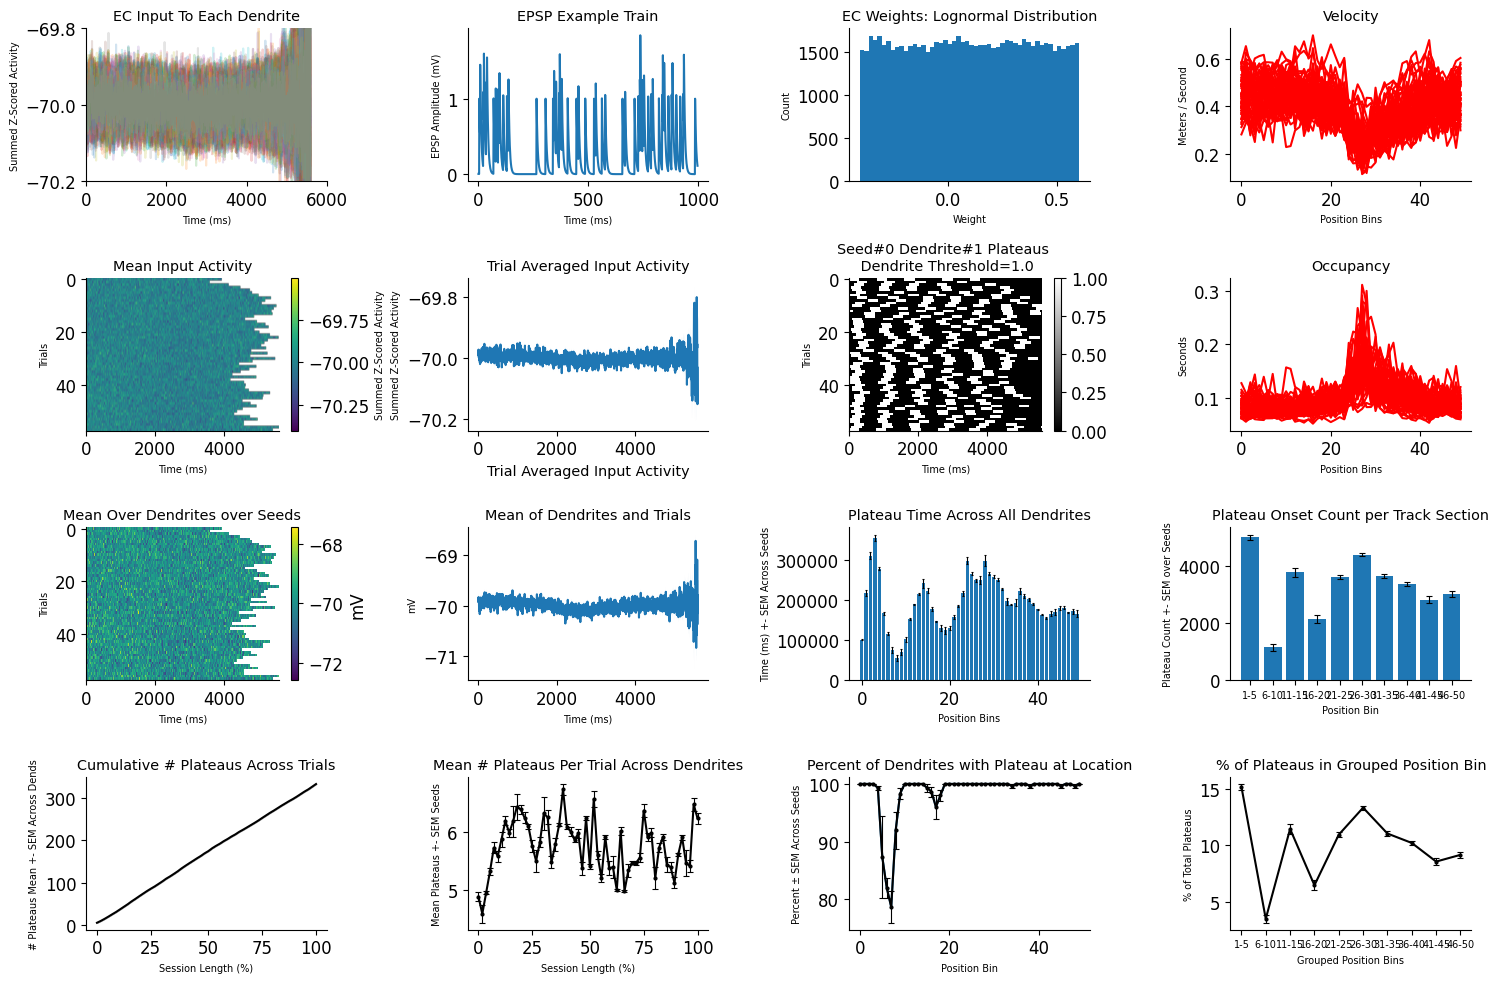

array([  4.95,   9.3 ,  14.28,  19.6 ,  25.19,  30.59,  36.62,  42.69,
        48.73,  55.4 ,  61.39,  67.65,  73.73,  79.77,  85.36,  90.66,
        96.59, 102.58, 109.07, 114.44, 120.33, 126.45, 133.31, 139.47,
       145.4 , 151.2 , 157.08, 162.65, 168.95, 174.33, 181.1 , 186.74,
       191.85, 197.78, 202.92, 208.69, 213.67, 219.67, 224.68, 229.98,
       235.44, 240.85, 246.49, 252.64, 258.56, 264.48, 269.89, 275.63,
       281.45, 286.85, 292.33, 297.36, 302.93, 308.91, 314.83, 320.1 ,
       326.38, 332.65])

In [17]:

vel_applied = "real"   #real or constant 

use_averaged_velocity="actual_velocity"
    
wt_dist = "Lognormal"   #Uniform, Constant, Lognormal 


add_inh = 'neither' #options: both, sst, neither

dend_threshold = 1.0


SST_bias_multi = 1.4


constant_vel=False
real_vel=True

SST_bias_factor = 2.0

dist = "Uniform"

make_it_spike=True

use_model_EC = True


dend_vm_per_seed_dict = {}
_pos_cnt_dict = {}
padded_warped_activity_list_dict = {}
start_pos_cnt50_dict = {}
_plateau_arr_list_dict = {}
_mask_dict = {}
num_plateaus_per_dend_dict = {}
_starts_list_dict = {}
last_EPSP_dict = {}
weights_EC_dict = {}
weights_SST_dict = {}
weights_NDNF_dict = {}
an_velocity_dict = {}
activity_SST_dict = {}
activity_NDNF_dict = {}
SST_sf_opt_dict = {}
NDNF_sf_opt_dict = {}


activity_NDNF = 0
activity_SST = 0

num_seeds=3

dendrite_contribution_EC_dict = {}


for seed in range(num_seeds):

    an_velocity, dendrite_contribution_EC, NDNF_pop_list, SST_pop_list, NDNF_sf_opt, SST_sf_opt, NDNF_contribution_sum, SST_contribution_sum, weights_EC, weights_SST, weights_NDNF, last_EPSP = get_dend_contribution(residual_activity_dict_EC, fixed_residual_activity_dict_NDNF_newest, residual_activity_dict_SST, factors_dict_EC, factors_dict_SST, factors_dict_NDNF_newest, GLM_params_EC, GLM_params_NDNF_newest, GLM_params_SST, mean_new_average_vel_array, real_vel=real_vel, constant_vel=constant_vel, use_residuals=True,  use_model_EC=use_model_EC, multiple_dendrites=True, add_inh=add_inh, SST_bias_factor=SST_bias_factor, dist=dist, use_averaged_velocity=use_averaged_velocity, make_it_spike=make_it_spike, seed=seed, store_intermediates=False)

#     # with open(save_path, 'wb') as f:
#     #     pickle.dump(dendrite_contribution_EC_dict, f)
#     #     print(f"pickle saved to {save_path}")


    padded_warped_activity_list, dend_vm, plateau_positions_counter, plateau_start_positions_counter, plateau_array_per_dendrite_list, dendrite_plateau_mask, time_each_pos_bin_starts, plateau_start_times_list_mega_list, EC_used, dist, num_plateaus_per_dend_list = get_activity_multidendrite(an_velocity, dendrite_contribution_EC, activity_NDNF, activity_SST, NDNF_sf_opt, SST_sf_opt, dend_threshold=-70, vel_applied=vel_applied, example_cell=17, dist=wt_dist, n_dendrites=100, n_SST=75, n_EC=792, n_NDNF=73, include_inhibition=add_inh, use_model_EC=False, make_it_spike=make_it_spike)

    
    dend_vm_per_seed_dict[seed] = dend_vm
    _pos_cnt_dict[seed] = plateau_positions_counter
    padded_warped_activity_list_dict[seed] = padded_warped_activity_list
    start_pos_cnt50_dict[seed] = plateau_start_positions_counter
    _plateau_arr_list_dict[seed] = plateau_array_per_dendrite_list
    _mask_dict[seed] = dendrite_plateau_mask
    num_plateaus_per_dend_dict[seed] = num_plateaus_per_dend_list
    _starts_list_dict[seed] = plateau_start_times_list_mega_list
    last_EPSP_dict[seed] = last_EPSP
    weights_EC_dict[seed] = weights_EC
    weights_SST_dict[seed] = weights_SST
    weights_NDNF_dict[seed] = weights_NDNF
    an_velocity_dict[seed] = an_velocity
    activity_SST_dict[seed] = activity_SST
    activity_NDNF_dict[seed] = activity_NDNF
    SST_sf_opt_dict[seed] = SST_sf_opt
    NDNF_sf_opt_dict[seed] = NDNF_sf_opt


important_dict = {}

important_dict["dend_vm_per_seed_dict"] = dend_vm_per_seed_dict
important_dict["_pos_cnt_dict"] = _pos_cnt_dict
important_dict["padded_warped_activity_list_dict"] = padded_warped_activity_list_dict
important_dict["start_pos_cnt50_dict"] = start_pos_cnt50_dict
important_dict["_plateau_arr_list_dict"] = _plateau_arr_list_dict
important_dict["_mask_dict"] = _mask_dict
important_dict["num_plateaus_per_dend_dict"] = num_plateaus_per_dend_dict
important_dict["_starts_list_dict"] = _starts_list_dict
important_dict["last_EPSP"] = last_EPSP_dict
important_dict["weights_EC"] = weights_EC_dict
important_dict["weights_SST_dict"] = weights_SST_dict
important_dict["weights_NDNF_dict"] = weights_NDNF_dict
important_dict["an_velocity_dict"] = an_velocity_dict
important_dict["activity_SST_dict"] = activity_SST_dict
important_dict["activity_NDNF_dict"] = activity_NDNF_dict
important_dict["SST_sf_opt_dict"] = SST_sf_opt_dict
important_dict["NDNF_sf_opt_dict"] = NDNF_sf_opt_dict





save_path = "/Users/michaelfinch/CA1-interneuron-GLM/vm_test/dendrite_contribution_EC_dict.pkl"
with open(save_path, 'wb') as f:
    pickle.dump(important_dict, f)
    # important_dict = pickle.load(f)




save_path = "/Users/michaelfinch/CA1-interneuron-GLM/vm_test/dendrite_contribution_EC_dict.pkl"
with open(save_path, 'rb') as f:
    important_dict = pickle.load(f)

dend_vm_per_seed_dict = important_dict["dend_vm_per_seed_dict"]
_pos_cnt_dict = important_dict["_pos_cnt_dict"]
padded_warped_activity_list_dict = important_dict["padded_warped_activity_list_dict"]
start_pos_cnt50_dict = important_dict["start_pos_cnt50_dict"]
_plateau_arr_list_dict = important_dict["_plateau_arr_list_dict"]
_mask_dict = important_dict["_mask_dict"]
num_plateaus_per_dend_dict = important_dict["num_plateaus_per_dend_dict"]
_starts_list_dict = important_dict["_starts_list_dict"]
last_EPSP_dict = important_dict["last_EPSP"]
weights_EC_dict = important_dict["weights_EC"]
weights_SST_dict = important_dict["weights_SST_dict"]
weights_NDNF_dict = important_dict["weights_NDNF_dict"]
an_velocity_dict = important_dict["an_velocity_dict"]
activity_SST_dict = important_dict["activity_SST_dict"]
activity_NDNF_dict = important_dict["activity_NDNF_dict"]
SST_sf_opt_dict = important_dict["SST_sf_opt_dict"]
NDNF_sf_opt_dict = important_dict["NDNF_sf_opt_dict"]

tau_ms = 5.0

last_EPSP = last_EPSP_dict[0]
weights_EC = weights_EC_dict[0]
weights_SST = weights_SST_dict[0]
weights_NDNF = weights_NDNF_dict[0]
activity_SST =  activity_SST_dict[0]
activity_NDNF = activity_NDNF_dict[0]
SST_sf_opt = SST_sf_opt_dict[0]
NDNF_sf_opt = NDNF_sf_opt_dict[0]
an_velocity = an_velocity_dict[0]




num_seeds = 3

#### need to get activity_EC / dendrite_contribution_EC

dendrite_contribution_EC = dend_vm_per_seed_dict[0]

plot_multidendrite_EC_err_across_seeds2(tau_ms,
np.arange(num_seeds), last_EPSP, weights_EC, weights_SST, weights_NDNF,  dend_vm_per_seed_dict,
dendrite_contribution_EC, activity_SST, activity_NDNF, SST_sf_opt, NDNF_sf_opt,
padded_warped_activity_list_dict, an_velocity, dend_threshold,
_pos_cnt_dict, start_pos_cnt50_dict, _plateau_arr_list_dict, _mask_dict,  _starts_list_dict,
dist, num_plateaus_per_dend_dict, animal, example_cell=1, include_inhibition=False,
NDNF_contribution_sum=None, SST_contribution_sum=None, animal_by_animal=False)




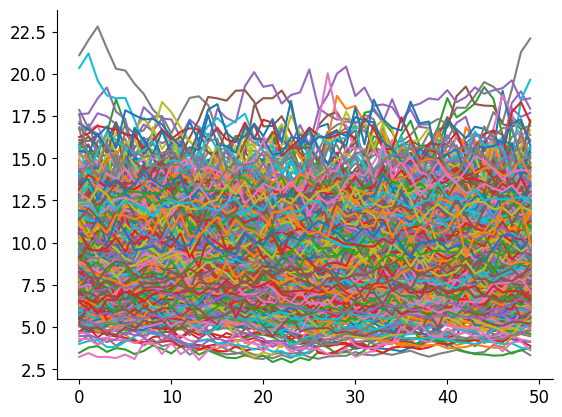

9.35947094972562
6.539215606494476


In [10]:
data_list_normalized = []

for animal in activity_dict_EC:
    for cell in activity_dict_EC[animal]:
        data_normalized = activity_dict_EC[animal][cell][:,:58]
        data_normalized = (data_normalized - np.min(data_normalized)) / (np.max(data_normalized) - np.min(data_normalized)) *50
        plt.plot(np.mean(data_normalized, axis=1))
        data_list_normalized.append(data_normalized)

plt.show()

data_array_normalized = np.array(data_list_normalized)

overall_mu= np.mean(data_array_normalized)
overall_std = np.std(data_array_normalized)

print(overall_mu)
print(overall_std)

In [ ]:

def get_vel_formatted(activity_dict_EC, factors_dict_EC):
    animal_velocity_list_cm_sec = []
    for animal in activity_dict_EC:
        for cell in activity_dict_EC[animal]:
            velocity = factors_dict_EC[animal]["Velocity"][:,:58]*100
            animal_velocity_list_cm_sec.append(velocity)
    
    return animal_velocity_list_cm_sec

def get_new_data_norm(activity_dict_EC, factors_dict_EC, use_cell_by_cell_mu=False):
    velocity_list = get_vel_formatted(activity_dict_EC, factors_dict_EC)

    all_betas = []

    for animal in GLM_params_EC:
        for cell in GLM_params_EC[animal]:
            all_betas.append(GLM_params_EC[animal][cell]['weights']["Velocity"])

    data_normalized_list = get_norm_data(activity_dict_EC, factors_dict_EC)
    data_normalized_array = np.array(data_normalized_list)


    if use_cell_by_cell_mu:
        mu_per_cell = np.mean(data_normalized_array, axis=(1,2))
        std_per_cell = np.std(data_normalized_array, axis=(1,2))

        print(mu_per_cell.shape)

        print(data_normalized_array.shape)


        data_vel_corr_list_ta_list = []
        data_vel_corr_list = []
        for cell in range(len(mu_per_cell)):
            data_constant_array = np.full((50,58), mu_per_cell[cell])
            data_vel_corr_array = data_constant_array + ((std_per_cell[cell])*(all_betas[cell])*(velocity_list[cell]))
            data_vel_corr_list.append(data_vel_corr_array)
            data_vel_corr_list_ta_list.append(np.mean(data_vel_corr_array, axis=1))

    else:
        overall_mu = np.mean(data_normalized_array)
        overall_std = np.std(data_normalized_array)

        print(f"mu{overall_mu} std{overall_std}")

        data_vel_corr_list_ta_list = []
        data_vel_corr_list = []
        for cell in range(data_normalized_array.shape[0]):
            data_constant_array = np.full((50,58), overall_mu)
            data_vel_corr_array = data_constant_array + (overall_std*(all_betas[cell])*(velocity_list[cell]))
            data_vel_corr_list.append(data_vel_corr_array)
            data_vel_corr_list_ta_list.append(np.mean(data_vel_corr_array, axis=1))

    return data_vel_corr_list_ta_list



data_vel_corr_list_ta_list = get_new_data_norm(activity_dict_EC, factors_dict_EC, use_cell_by_cell_mu=False)



### std and mu on a cell by cell basis 

plt.plot(data_vel_corr_list_ta_list[0])
plt.title("Cell 1 Trial Averaged")
plt.ylabel("Hz")
plt.xlabel("Position Bins")
plt.show()

for i in range(len(data_vel_corr_list_ta_list)):
    plt.plot(data_vel_corr_list_ta_list[i])
plt.title("All Trial Averaged Cells Activity")
plt.ylabel("Hz")
plt.xlabel("Position Bins")
plt.show()

data_vel_corr_list_ta_array = np.array(data_vel_corr_list_ta_list)
plt.imshow(data_vel_corr_list_ta_array, aspect='auto')
plt.title("All Trial Averaged Cells Activity")
plt.colorbar(label='Hz')
plt.xlabel("Position Bins")
plt.ylabel("EC Cell")
plt.show()


# plt.plot(mu_per_cell)
# plt.ylabel("Mu Value From Min/Max")
# plt.xlabel("EC Cell #")
# plt.show()


# plt.plot(std_per_cell)
# plt.ylabel("Std Value From Min/Max")
# plt.xlabel("EC Cell #")
# plt.show()


KeyboardInterrupt: 

In [ ]:
def _eval_one_seed(params, seed, static):
        tau_ms         = float(params["tau_ms"])
        weights_mean   = float(params["weights_mean"])
        weights_std    = float(params["weights_std"])
        dend_threshold = float(params["dend_threshold"])

        n_dendrites     = int(static["n_dendrites"])
        n_EC            = int(static["n_EC"])
        animal_velocity = np.asarray(static["animal_velocity"], dtype=np.float32, order="C")
        pwa_cell_dict   = static["pwa_cell_dict"]

        # --- EPSPs (ensure float32 path) ---
        epsp_cells, _ = get_epsp_dict_animal(pwa_cell_dict, tau_ms=tau_ms, amp=1., seed=int(seed))
        _, epsp_eTN, _ = get_dend_vm_from_cells_multi(
            epsp_cells, Vrest=np.float32(static["vrest"]), epsp_sf=np.float32(static["epsp_sf"])
        )
        # want (E, T, N)
        if epsp_eTN.shape[1] != animal_velocity.shape[1]:
            epsp_eTN = np.transpose(epsp_eTN, (0, 2, 1))
        epsp_eTN = np.ascontiguousarray(epsp_eTN, dtype=np.float32)

        # --- Weights (float32) ---
        rng = np.random.default_rng(12345 + int(seed))
        connection_mask_EC = np.ones((n_dendrites, n_EC), dtype=np.bool_)
        weights_EC = sample_weights(
            static["dist"], connection_mask_EC, rng=rng,
            mean=weights_mean, std=weights_std
        ).astype(np.float32, copy=False)

        # --- EC activity -> dendritic Vm (float32, contiguous) ---
        activity_EC = get_dendrite_activity_multi(weights_EC, epsp_eTN, n_dendrites, n_EC)
        activity_EC = np.asarray(activity_EC, dtype=np.float32, order="C")
        dend_Vm, _, _ = activity_to_dend_vm(
            activity_EC, Vrest=np.float32(-70.0), vm_scale=np.float32(0.1), center_across="time_trials"
        )

        # --- Plateaus: ask NOT to build/store huge arrays ---
        res = get_activity_multidendrite2(
            animal_velocity, dend_Vm,
            activity_NDNF=0, activity_SST=0, NDNF_sf_opt=0, SST_sf_opt=0,
            dt_constant=static["dt_constant"], dx=static["dx"], dend_threshold=np.float32(dend_threshold),
            vel_applied="real", example_cell=15, include_inhibition=None, use_model_EC=False,
            store_arrays=False,  # <---- IMPORTANT
        )
        # Pull only what you need
        start_pos_cnt50 = res[1]                      # (50,) int counts
        num_plateaus_per_dend_list = res[5]           # list/array per dendrite

        # --- runtime hygiene: drop big temps immediately ---
        try: del epsp_cells
        except NameError: pass
        try: del epsp_eTN
        except NameError: pass
        try: del weights_EC
        except NameError: pass
        try: del activity_EC
        except NameError: pass
        try: del dend_Vm
        except NameError: pass
        # Optional: import gc; gc.collect()

        return start_pos_cnt50, np.asarray(num_plateaus_per_dend_list, dtype=np.float32)